In [3]:
!pip install plotly

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [5]:
df=pd.read_csv('Travel.csv')
df.head(4)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0


In [6]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [7]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].median(),inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode(),inplace=True)
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(),inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].median(),inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(),inplace=True)

In [8]:
df['TypeofContact'].fillna('Other',inplace=True)

In [9]:
mapping = {
    'Self Enquiry': 0,
    'Company Invited': 1,
    'Other': -1
}

df['TypeofContact'] = df['TypeofContact'].map(mapping)

In [10]:
df['TypeofContact'].value_counts()

TypeofContact
 0    3444
 1    1419
-1      25
Name: count, dtype: int64

In [11]:
#can combine children and people visitng 
df['TotalNoOfPeopleVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)

In [12]:
df.head(5)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalNoOfPeopleVisiting
0,200000,1,41.0,0,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,200001,0,49.0,1,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,200002,1,37.0,0,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,200003,0,33.0,1,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,200004,0,36.0,0,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [13]:
print(df['TypeofContact'].unique())
print(df['Occupation'].unique())
print(df['ProductPitched'].unique())
print(df['MaritalStatus'].unique())
print(df['Designation'].unique())
print(df['Gender'].unique())

[ 0  1 -1]
['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
['Single' 'Divorced' 'Married' 'Unmarried']
['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']
['Female' 'Male' 'Fe Male']


In [14]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()


In [15]:
x=df.duplicated()
cnt=0
for i in x:
    if i==True:
        cnt+=1
print(cnt)
#no duplicate

0


<Axes: ylabel='MonthlyIncome'>

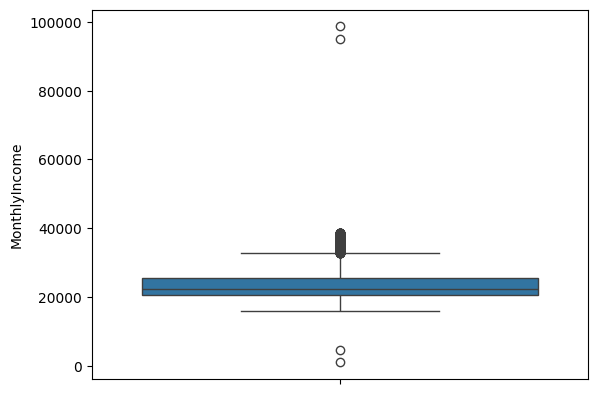

In [16]:
sns.boxplot(df['MonthlyIncome'])
##definetly some outliers 

In [17]:
#my idea age-median,duration of pitch-median,nof-median,not-median,nocv,income can be filled with median,
# ['Self Enquiry' 'Company Invited' nan] -> encode as->0,1,
# ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']onehotencoding
# ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']label encoding
# ['Single' 'Divorced' 'Married' 'Unmarried'],onehotencoding ,single and unmarried are same arent they>
# ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP'],label encoding

In [18]:
## let put Unmarrid as single
df['MaritalStatus'].replace('Unmarried','Single',inplace=True)
df['Gender'].replace('Fe Male','Female',inplace=True)

In [19]:
df['Gender']=np.where(df['Gender'].str.contains('Male'),1,0)

In [20]:
package_pitched={
    'Deluxe':3, 'Basic':0, 'Standard':1, 'Super Deluxe':4, 'King':2
}
df['ProductPitched']=df['ProductPitched'].map(package_pitched)

In [21]:
Designation_map={
    'Manager':0, 'Executive':2, 'Senior Manager':1, 'AVP':3, 'VP':4
}
df['Designation']=df['Designation'].map(Designation_map)

In [22]:
df.head(4)
df.drop('CustomerID',axis=1,inplace=True)

In [23]:
X = df.drop('ProductPitched', axis=1)
y = df['ProductPitched']
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [24]:
numerical_col=X.select_dtypes(exclude='object').columns


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), ['Occupation','MaritalStatus']),
        ('num',StandardScaler(),numerical_col)
    ],
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test =ct.transform(X_test)

In [26]:
ct.get_feature_names_out()

array(['encoder__Occupation_Free Lancer',
       'encoder__Occupation_Large Business',
       'encoder__Occupation_Salaried',
       'encoder__Occupation_Small Business',
       'encoder__MaritalStatus_Divorced',
       'encoder__MaritalStatus_Married', 'encoder__MaritalStatus_Single',
       'num__ProdTaken', 'num__Age', 'num__TypeofContact',
       'num__CityTier', 'num__DurationOfPitch', 'num__Gender',
       'num__NumberOfFollowups', 'num__PreferredPropertyStar',
       'num__NumberOfTrips', 'num__Passport',
       'num__PitchSatisfactionScore', 'num__OwnCar', 'num__Designation',
       'num__MonthlyIncome', 'num__TotalNoOfPeopleVisiting'], dtype=object)

In [36]:
#Now we will train the model
from sklearn.ensemble import RandomForestClassifier
random=RandomForestClassifier()

random.fit(X_train,Y_train)
y_pred=random.predict(X_test)

from sklearn.metrics import classification_report,accuracy_score,roc_auc_score
print(classification_report(Y_test,y_pred))
print(accuracy_score(Y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00       179
           2       1.00      0.98      0.99        66
           3       1.00      1.00      1.00       421
           4       1.00      0.99      0.99        93

    accuracy                           1.00      1222
   macro avg       1.00      0.99      1.00      1222
weighted avg       1.00      1.00      1.00      1222

0.9983633387888707


## From above it might be overfiting the data because the accuracy 1 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00       179
           2       1.00      0.98      0.99        66
           3       1.00      1.00      1.00       421
           4       1.00      0.99      0.99        93

    accuracy                           1.00      1222
   macro avg       1.00      0.99      1.00      1222
weighted avg       1.00      1.00      1.00      1222


Accuracy Score:
0.9983633387888707

ROC-AUC Score (Multi-class):

Precision Score:
0.9983703781919293

Recall Score:
0.9983633387888707

F1 Score:
0.9983597673288199


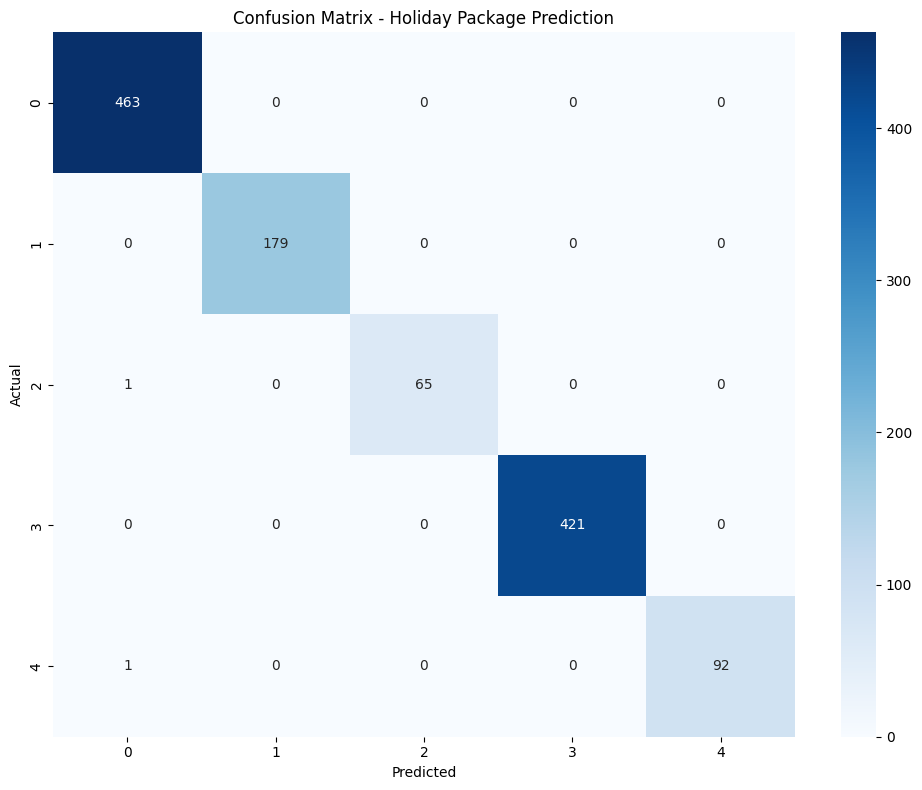


Top 10 Feature Importance:
                         Feature  Importance
19              num__Designation    0.560724
20            num__MonthlyIncome    0.209729
8                       num__Age    0.062304
10                 num__CityTier    0.024139
11          num__DurationOfPitch    0.022496
21  num__TotalNoOfPeopleVisiting    0.018447
15            num__NumberOfTrips    0.015411
13        num__NumberOfFollowups    0.012898
17   num__PitchSatisfactionScore    0.011897
14    num__PreferredPropertyStar    0.011613


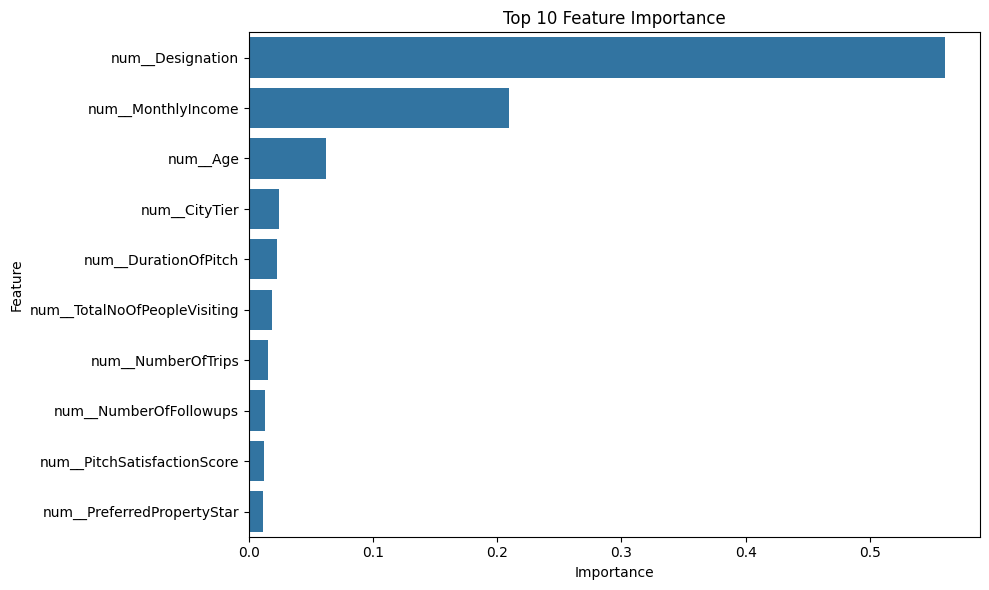

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train the model
random = RandomForestClassifier(random_state=42)
random.fit(X_train, Y_train)
y_pred = random.predict(X_test)

# Method 1: Fix roc_auc_score for multi-class
print("Classification Report:")
print(classification_report(Y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(Y_test, y_pred))

print("\nROC-AUC Score (Multi-class):")

# 'ovr' = One-vs-Rest, 'ovo' = One-vs-One

# Method 2: Additional metrics for multi-class
from sklearn.metrics import precision_score, recall_score, f1_score

print("\nPrecision Score:")
print(precision_score(Y_test, y_pred, average='weighted', zero_division=0))

print("\nRecall Score:")
print(recall_score(Y_test, y_pred, average='weighted', zero_division=0))

print("\nF1 Score:")
print(f1_score(Y_test, y_pred, average='weighted', zero_division=0))

# Method 3: Confusion Matrix visualization
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Holiday Package Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Method 4: Feature importance
feature_importance = pd.DataFrame({
    'Feature': ct.get_feature_names_out(),
    'Importance': random.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importance:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()